# Notebook 2: Basic scRNA-seq Analysis — Clustering, Marker Genes, and Cell Type Annotation

**Objective:** Perform PCA, compute neighborhood graphs, cluster cells with Leiden, visualize with UMAP, identify marker genes, and annotate cell types.

**Reference:** [Galaxy Training — Clustering 3K PBMCs with Scanpy](https://training.galaxyproject.org/training-material/topics/single-cell/tutorials/scrna-scanpy-pbmc3k/tutorial.html) | [Scanpy Preprocessing & Clustering Tutorial (updated)](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html)

**Input:** Preprocessed `.h5ad` file from Notebook 1

## 1. Setup and Load Preprocessed Data

In [21]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')
sc.settings.figdir = 'output_data/'

# Load preprocessed data from Notebook 1 (using relative path)
adata = sc.read_h5ad('../1_Preprocessing/output_data/preprocessed_adata.h5ad')
print(adata)

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'


## 2. Principal Component Analysis (PCA)

PCA reduces the high-dimensional gene expression space to its top principal components (PCs). This removes noise and speeds up downstream analysis.

In [22]:
sc.tl.pca(adata, svd_solver='arpack')

print(f"PCA computed. Shape of PCA embedding: {adata.obsm['X_pca'].shape}")
print(f"Variance ratios (first 10 PCs): {adata.uns['pca']['variance_ratio'][:10]}")

computing PCA
    with n_comps=50
    finished (0:00:00)
PCA computed. Shape of PCA embedding: (2638, 50)
Variance ratios (first 10 PCs): [0.02012813 0.01173344 0.00978356 0.00829649 0.00301059 0.00249868
 0.00221029 0.00202704 0.00195667 0.00192777]


### 2.1 PCA Scatter Plot

Visualize cells in the first two PC dimensions.

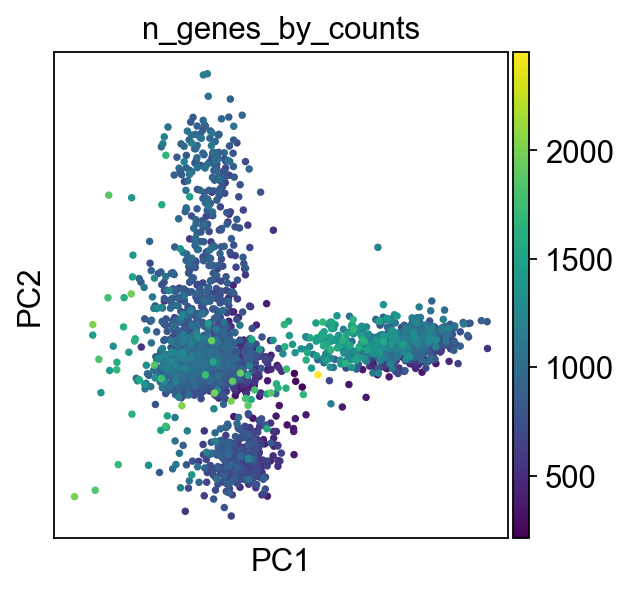

In [23]:
sc.pl.pca(adata, color='n_genes_by_counts', save='_scatter.png')
plt.show()

### 2.2 Elbow Plot (Variance Ratio)

The elbow plot helps determine how many PCs to retain. We look for the "elbow" — the point where additional PCs contribute diminishing variance.

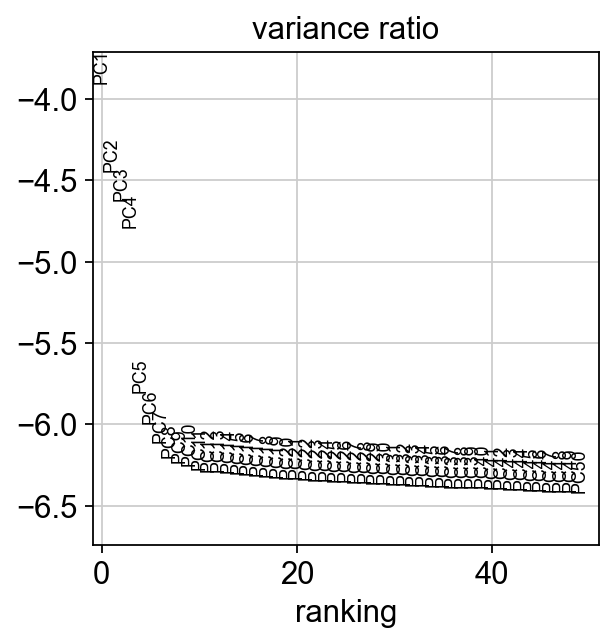

Based on the elbow plot, we will use 40 PCs for the neighborhood graph.


In [24]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True, save='_elbow.png')
plt.show()
print("Based on the elbow plot, we will use 40 PCs for the neighborhood graph.")

## 3. Computing the Neighborhood Graph

The neighborhood graph captures the local similarity structure between cells. Each cell is connected to its `n_neighbors` nearest neighbors in PCA space.

In [25]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
print("Neighborhood graph computed.")

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
Neighborhood graph computed.


## 4. UMAP Embedding

UMAP (Uniform Manifold Approximation and Projection) embeds the neighborhood graph into 2D for visualization. Cells that are transcriptionally similar appear close together.

In [26]:
sc.tl.umap(adata)
print(f"UMAP embedding shape: {adata.obsm['X_umap'].shape}")

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:02)
UMAP embedding shape: (2638, 2)


## 5. Clustering (Leiden Algorithm)

The Leiden algorithm partitions the neighborhood graph into clusters of transcriptionally similar cells. The `resolution` parameter controls cluster granularity (higher = more clusters).

In [27]:
sc.tl.leiden(adata, resolution=0.5)

print(f"Number of clusters found: {adata.obs['leiden'].nunique()}")
print(f"Cells per cluster:\n{adata.obs['leiden'].value_counts().sort_index()}")

running Leiden clustering
    finished: found 6 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
Number of clusters found: 6
Cells per cluster:
leiden
0    1182
1     636
2     430
3     341
4      36
5      13
Name: count, dtype: int64


### 5.1 UMAP Visualization Colored by Cluster

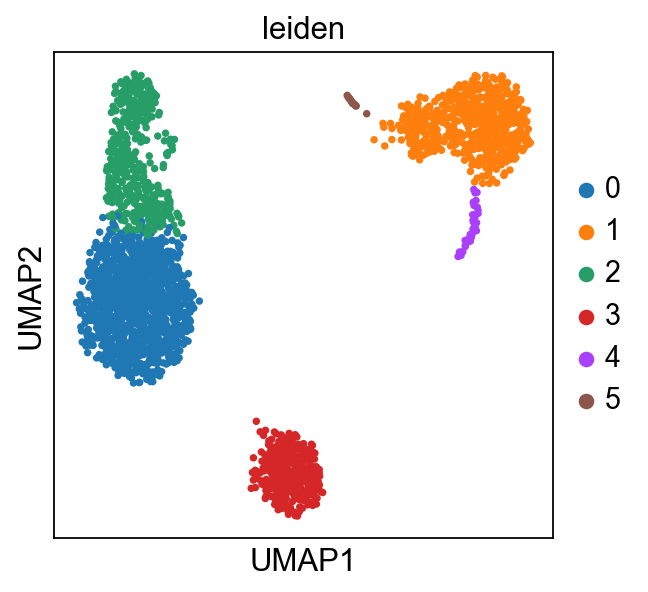

In [28]:
sc.pl.umap(adata, color=['leiden'], save='_clusters.png')
plt.show()

### 5.2 UMAP Colored by QC Metrics

Overlay QC metrics on UMAP to check that clusters are not driven by technical artifacts.

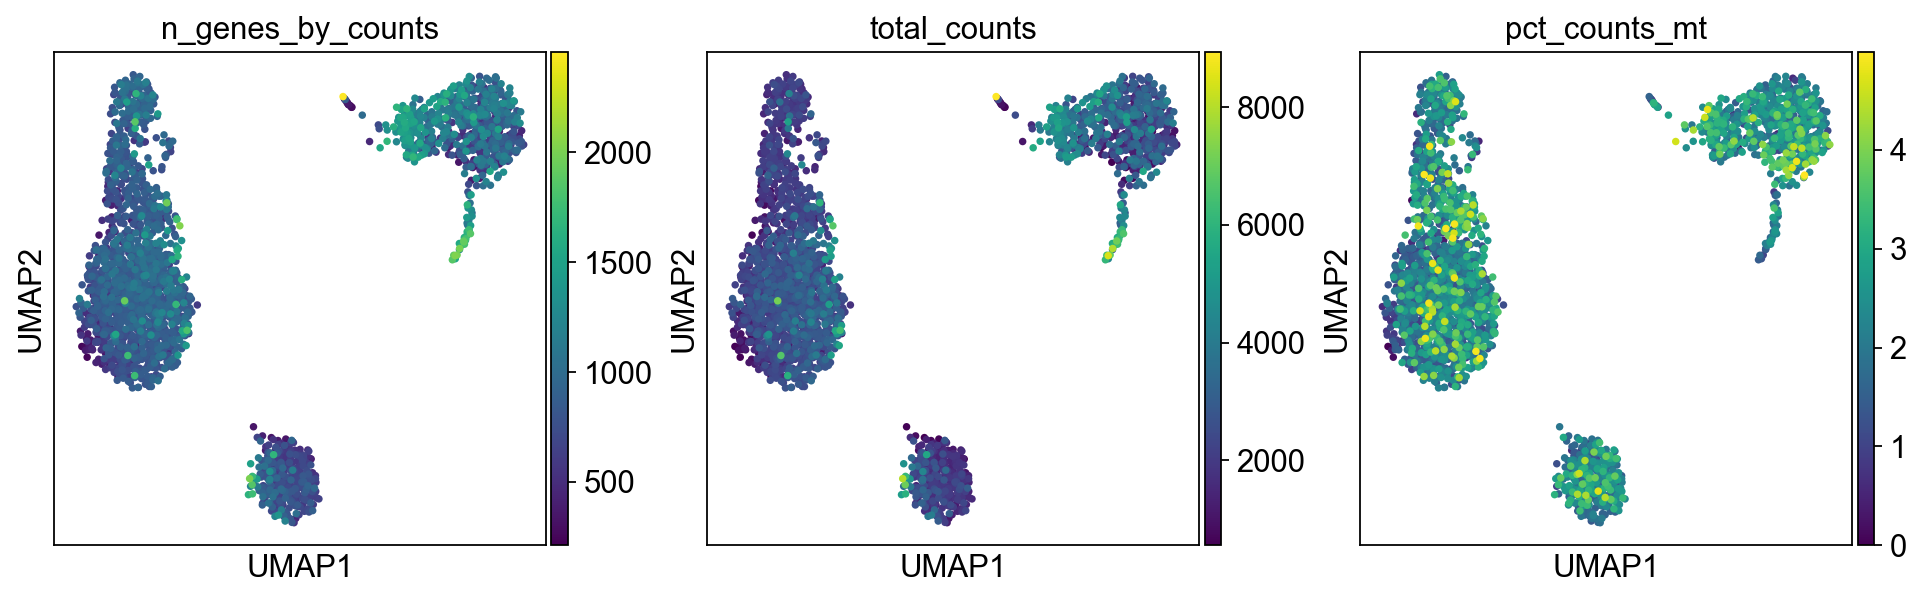

In [29]:
sc.pl.umap(
    adata,
    color=['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    save='_qc_overlay.png'
)
plt.show()

## 6. Finding Marker Genes

Marker genes are differentially expressed in one cluster compared to all others. We use both the t-test and Wilcoxon rank-sum test.

### 6.1 Marker Genes via t-test

In [30]:
sc.tl.rank_genes_groups(adata, groupby='leiden', method='t-test')

# Show top 5 marker genes per cluster
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names

print("Top 5 marker genes per cluster (t-test):")
print("=" * 60)
top_n = 5
for group in groups:
    genes = result['names'][group][:top_n]
    scores = result['scores'][group][:top_n]
    print(f"  Cluster {group}: {', '.join(genes)}")

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
Top 5 marker genes per cluster (t-test):
  Cluster 0: LDHB, CD3D, RPS12, RPS25, RPS27
  Cluster 1: FTL, CST3, TYROBP, FTH1, AIF1
  Cluster 2: NKG7, CST7, GZMA, B2M, CCL5
  Cluster 3: CD74, HLA-DRA, HLA-DPB1, CD79A, HLA-DRB1
  Cluster 4: HLA-DRA, CD74, CST3, HLA-DPA1, HLA-DPB1
  Cluster 5: GPX1, PF4, PPBP, CALM3, NRGN


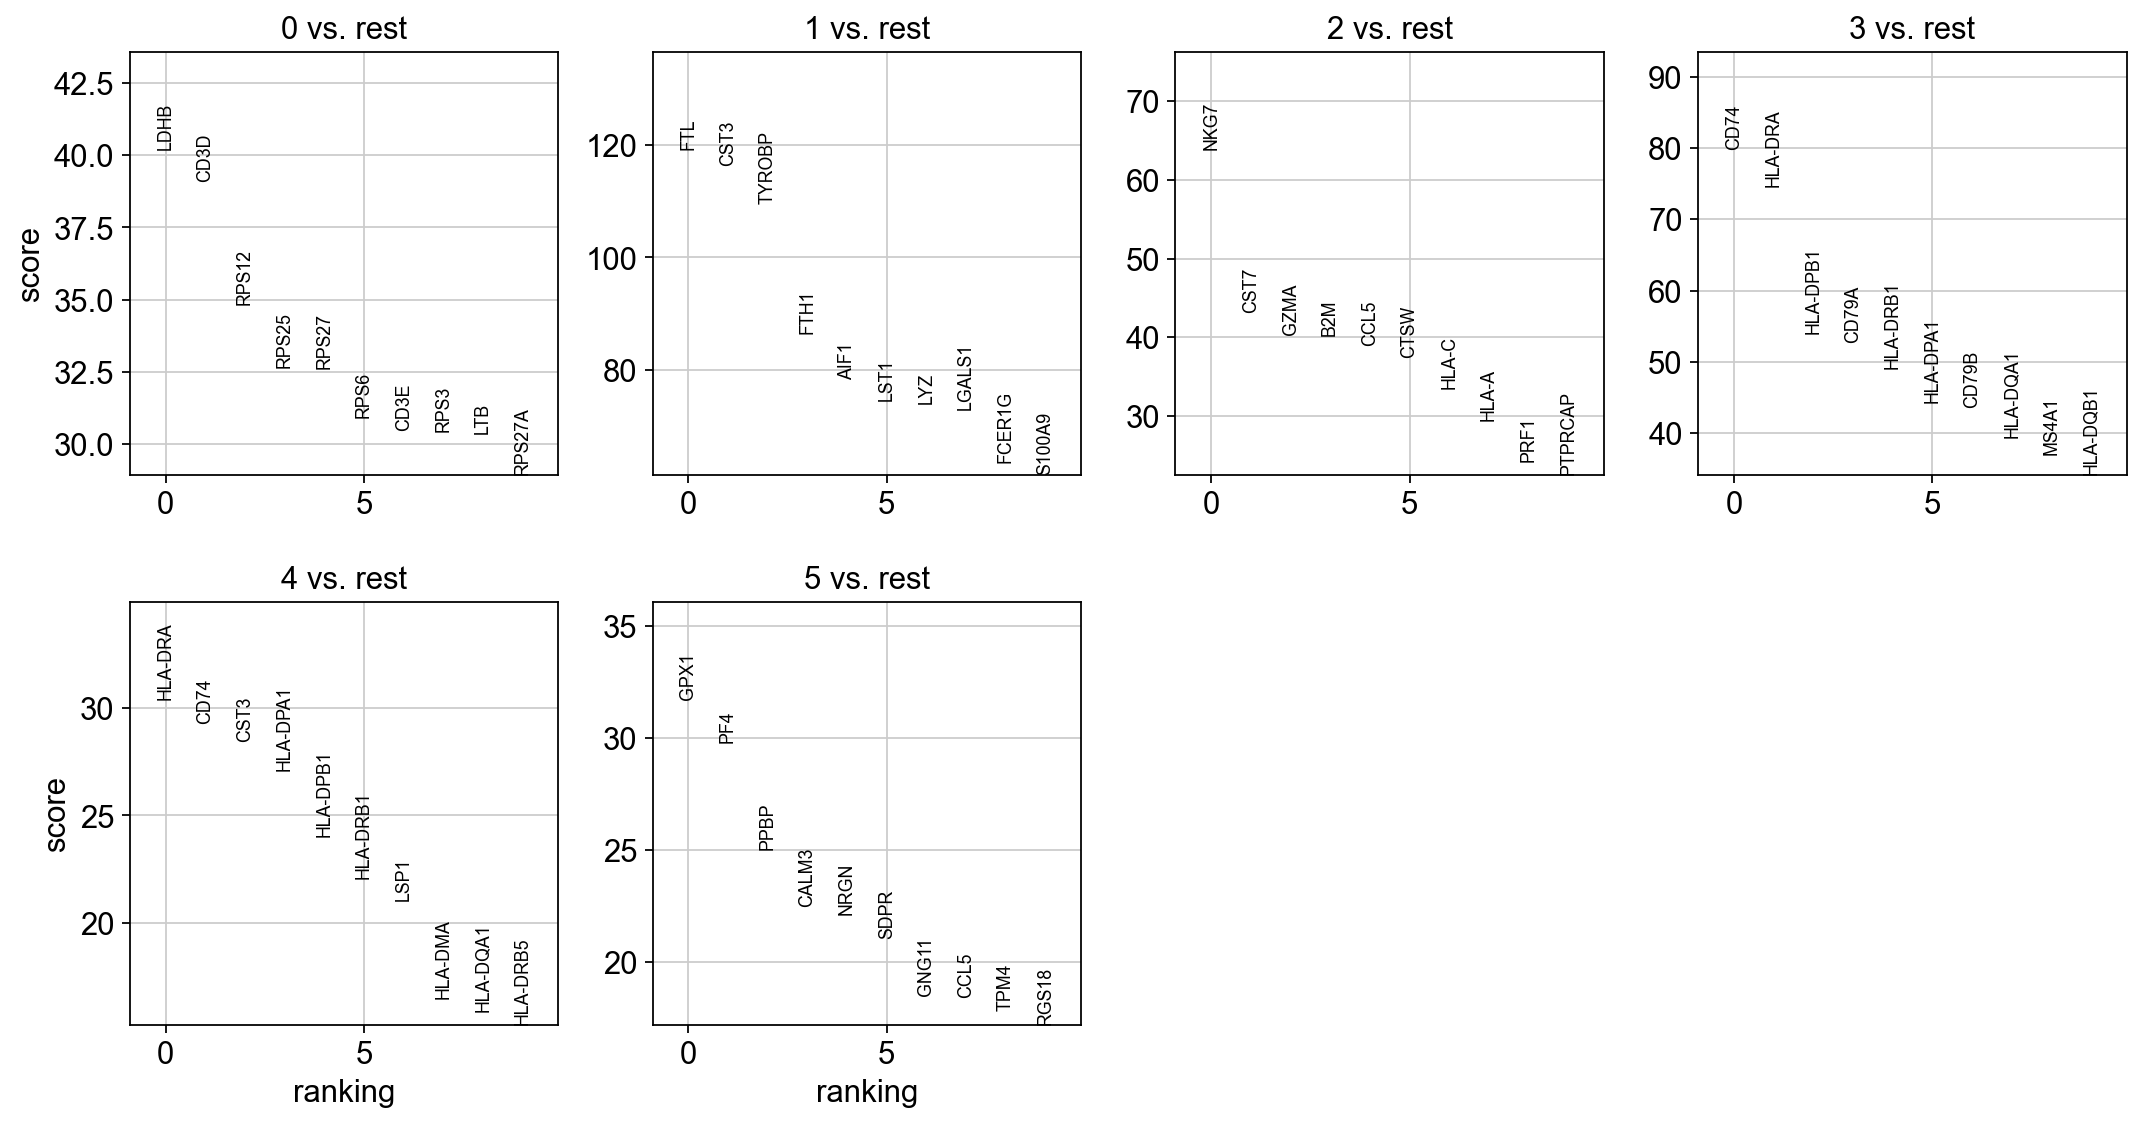

In [31]:
# Visualize the ranking
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False, save='_ttest.png')
plt.show()

### 6.2 Marker Genes via Wilcoxon Rank-Sum Test

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


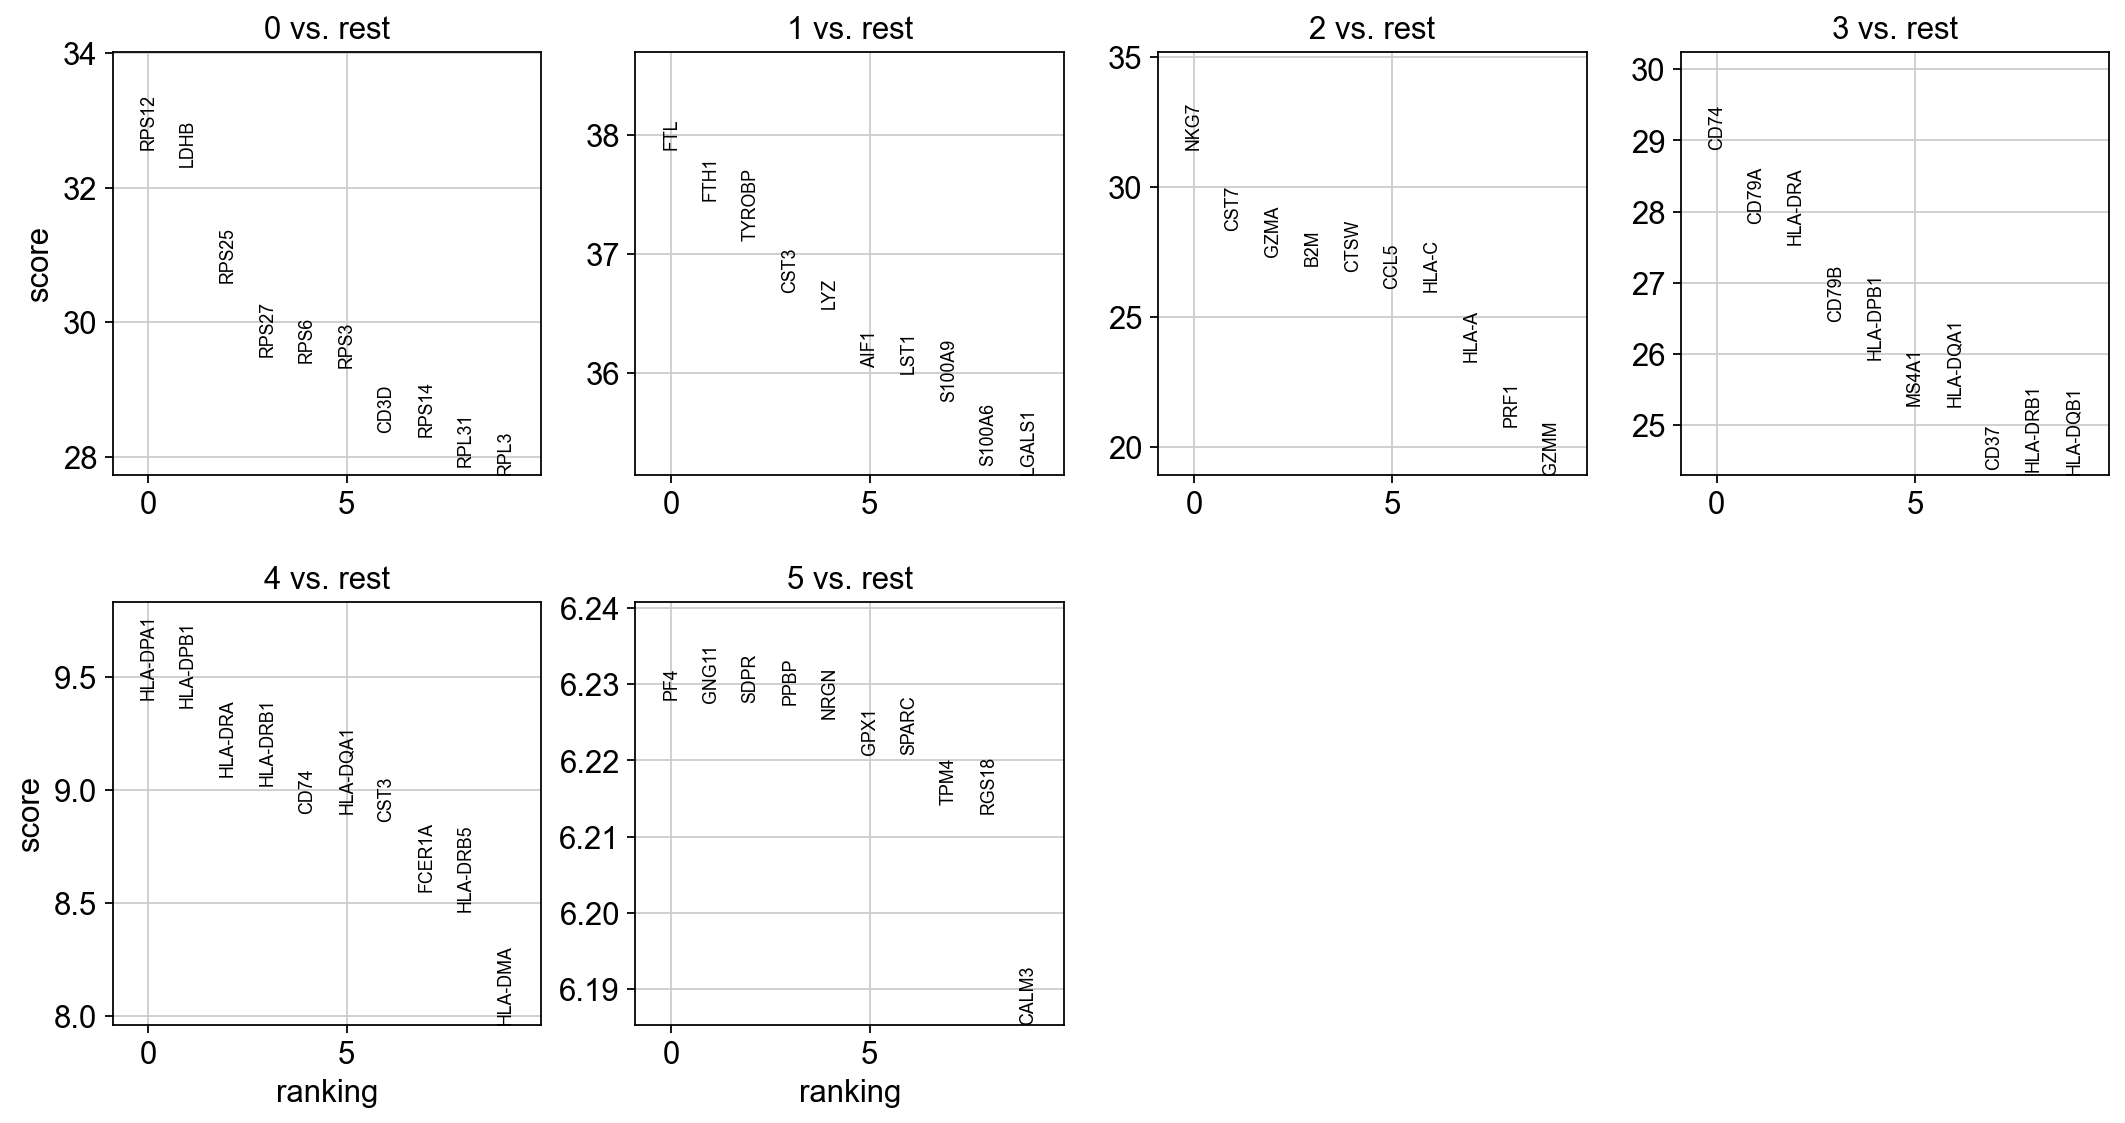

Wilcoxon rank-sum test complete.


In [32]:
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')

sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False, save='_wilcoxon.png')
plt.show()
print("Wilcoxon rank-sum test complete.")

### 6.3 Dotplot of Top Marker Genes

The dotplot shows both the fraction of cells expressing each gene (dot size) and the mean expression level (color) across clusters.

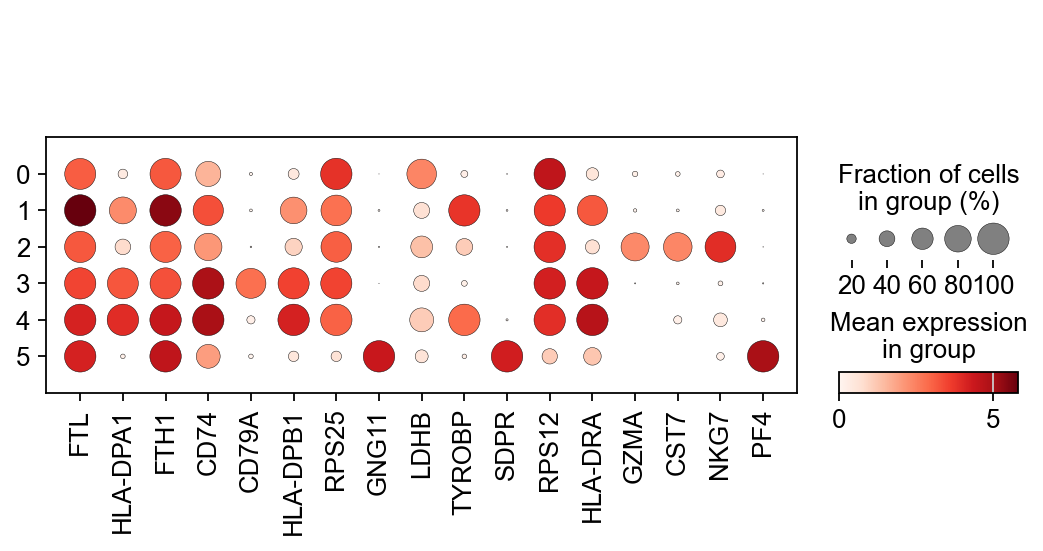

In [33]:
# Get top 3 markers per cluster for the dotplot
marker_genes = pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(3)
marker_list = list(set(marker_genes.values.flatten()))

sc.pl.dotplot(adata, var_names=marker_list, groupby='leiden', save='_markers.png')
plt.show()

### 6.4 Heatmap of Top Marker Genes

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden']`


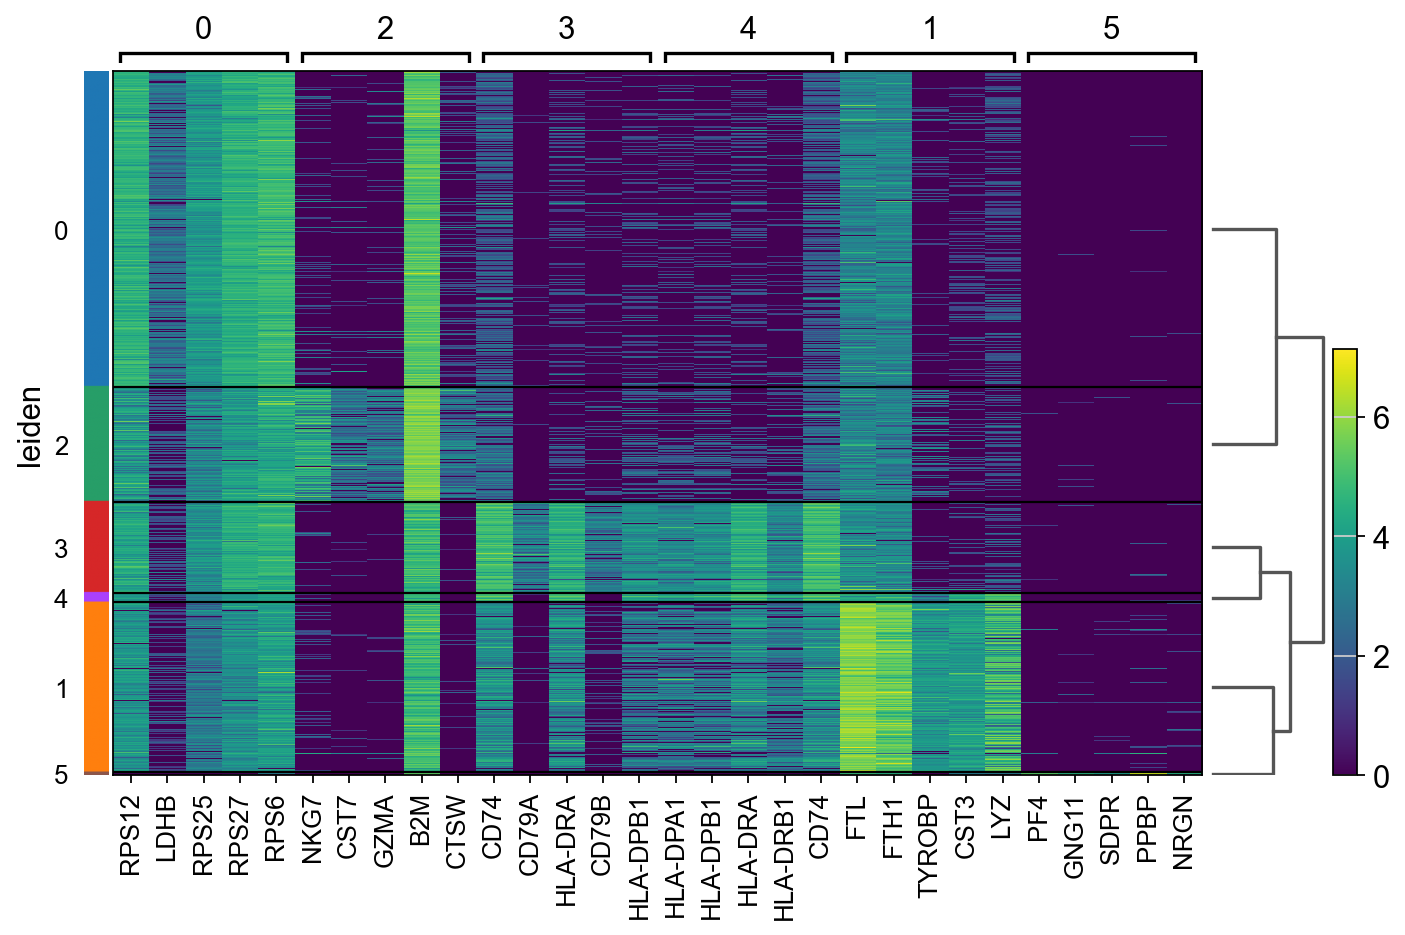

In [34]:
sc.pl.rank_genes_groups_heatmap(
    adata,
    n_genes=5,
    groupby='leiden',
    show_gene_labels=True,
    save='_markers_heatmap.png'
)
plt.show()

## 7. Cell Type Annotation

Using known PBMC marker genes, we can assign biological identity to each cluster. Common PBMC markers:

| Cell Type | Marker Genes |
|-----------|--------------|
| CD4+ T cells | IL7R, CD4 |
| CD14+ Monocytes | CD14, LYZ |
| B cells | MS4A1 (CD20) |
| CD8+ T cells | CD8A |
| NK cells | GNLY, NKG7 |
| FCGR3A+ Monocytes | FCGR3A, MS4A7 |
| Dendritic cells | FCER1A, CST3 |
| Megakaryocytes | PPBP |

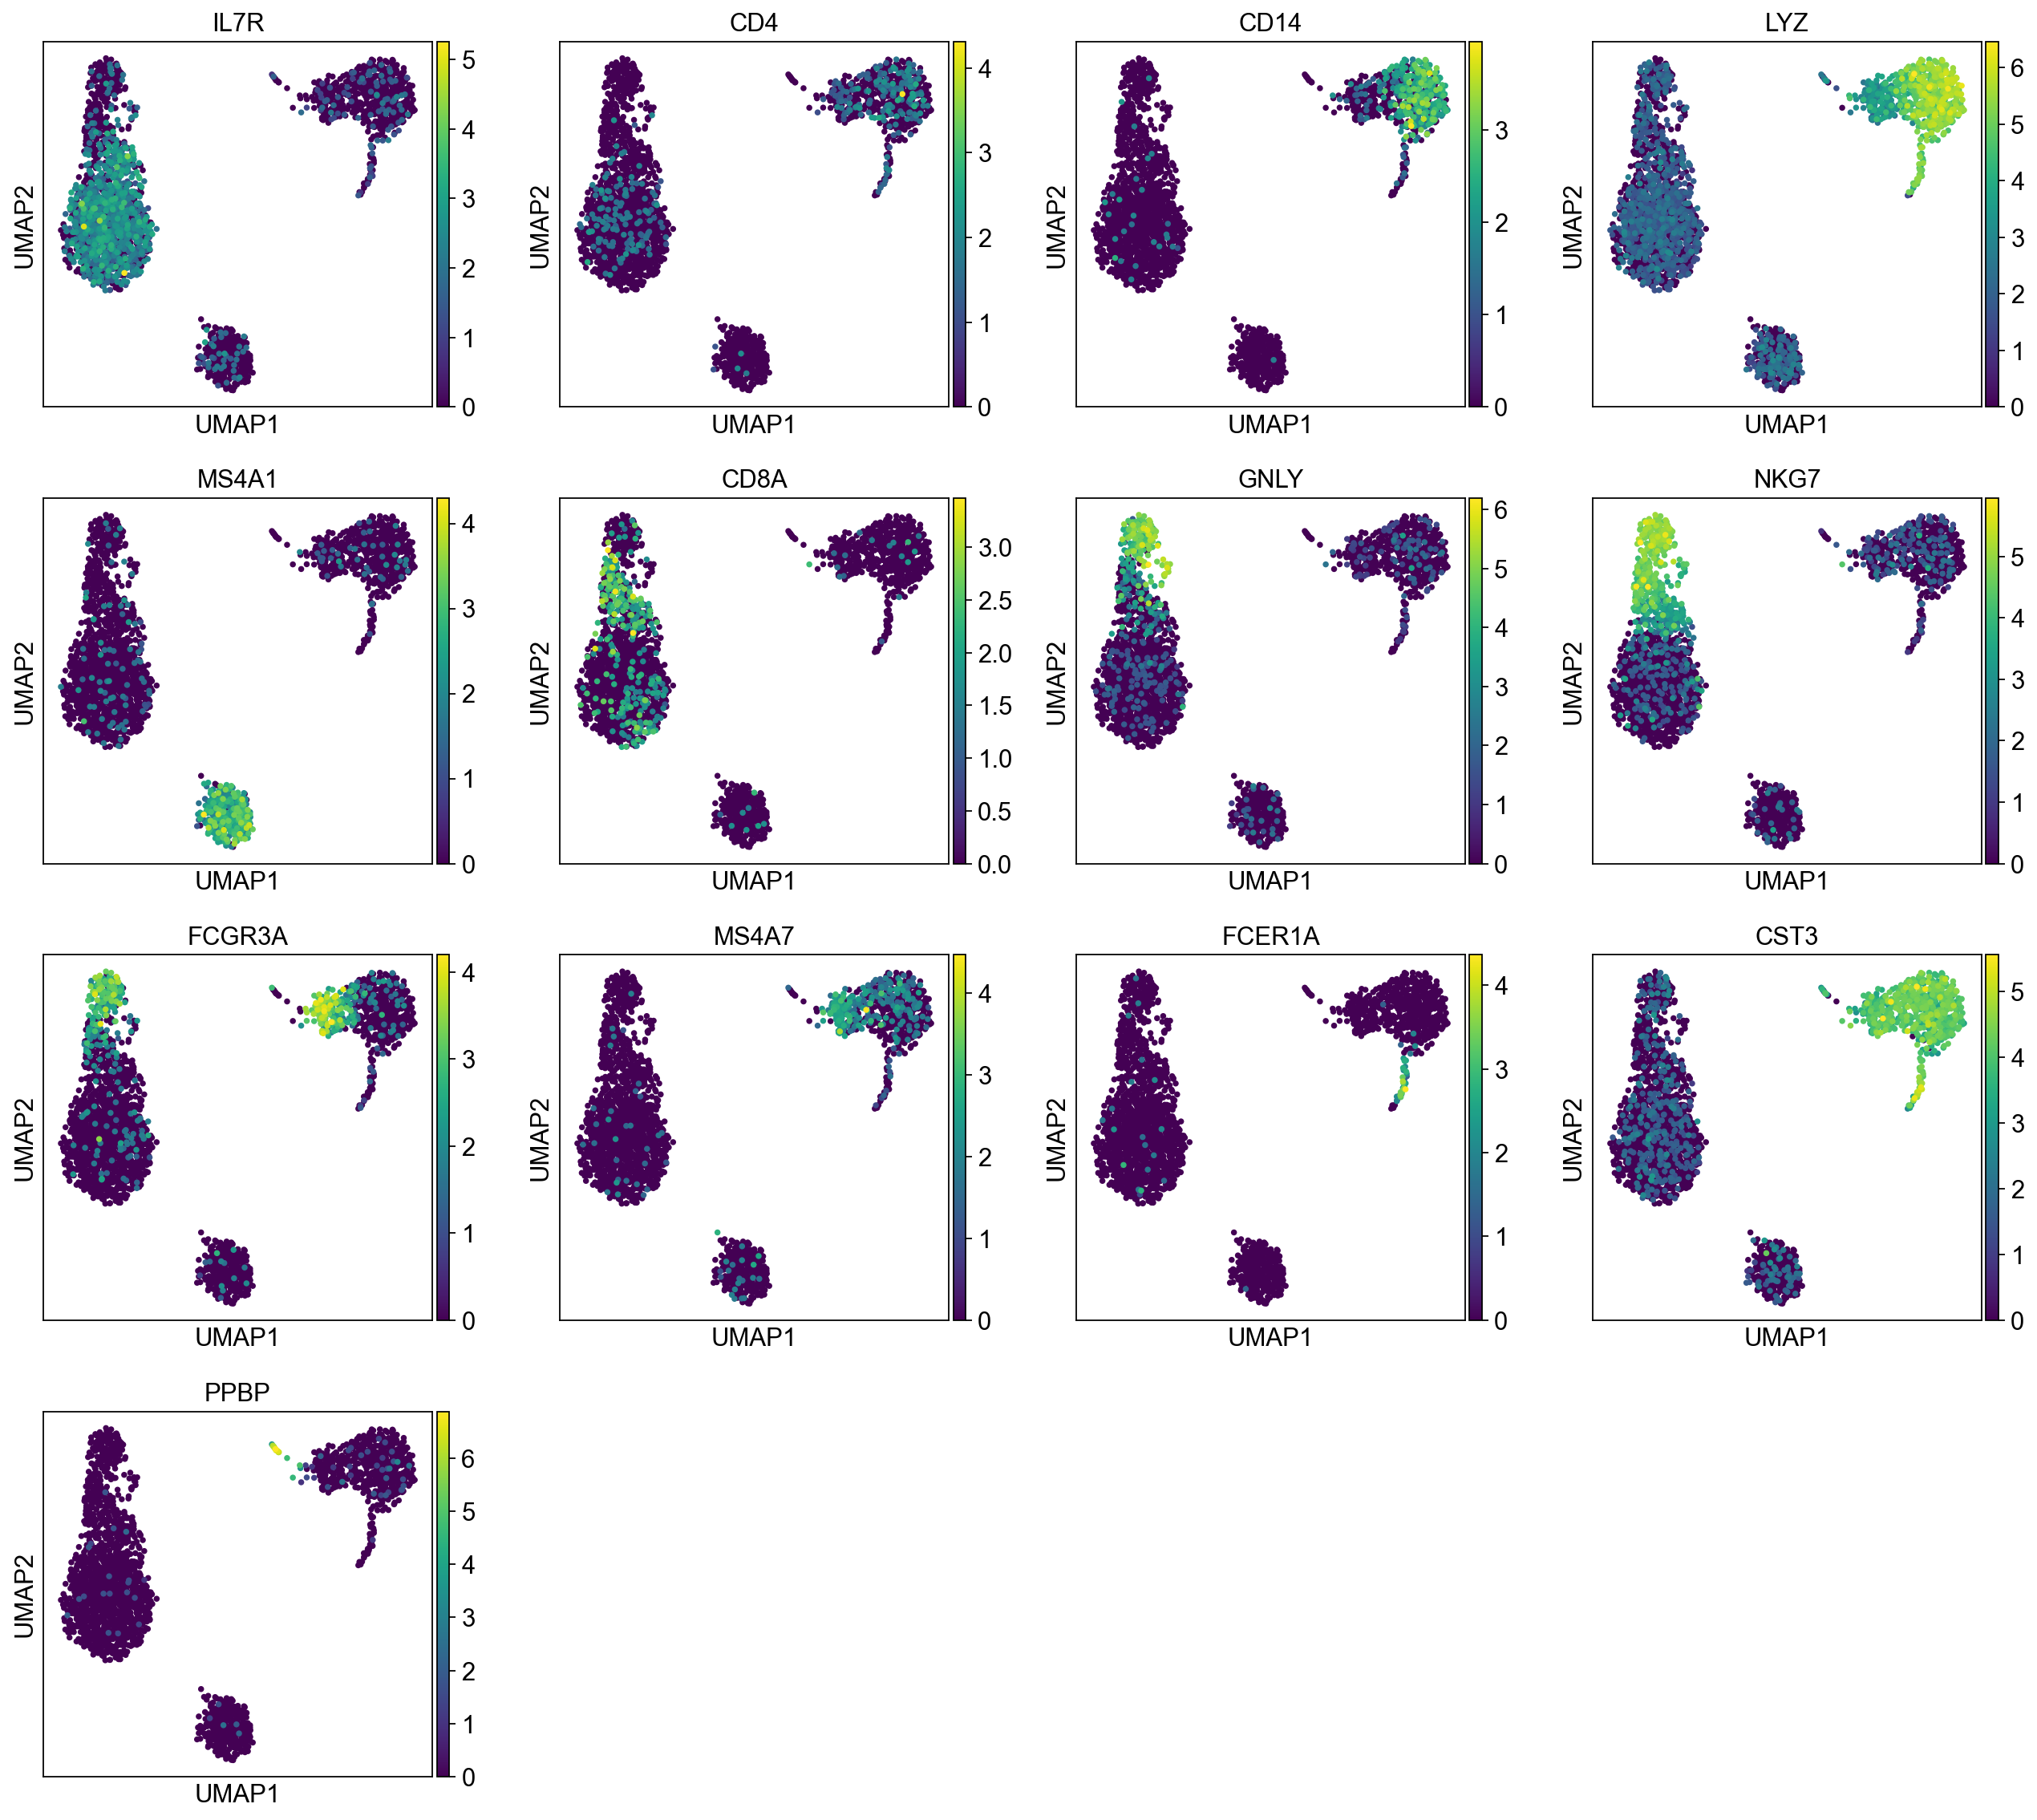

In [35]:
# Visualize known PBMC marker genes on UMAP
marker_genes_dict = {
    'CD4 T': ['IL7R', 'CD4'],
    'CD14 Mono': ['CD14', 'LYZ'],
    'B cell': ['MS4A1'],
    'CD8 T': ['CD8A'],
    'NK': ['GNLY', 'NKG7'],
    'FCGR3A Mono': ['FCGR3A', 'MS4A7'],
    'DC': ['FCER1A', 'CST3'],
    'Megakaryocyte': ['PPBP'],
}

# Flatten marker list
all_markers = [g for genes in marker_genes_dict.values() for g in genes]

sc.pl.umap(adata, color=all_markers, save='_known_markers.png')
plt.show()

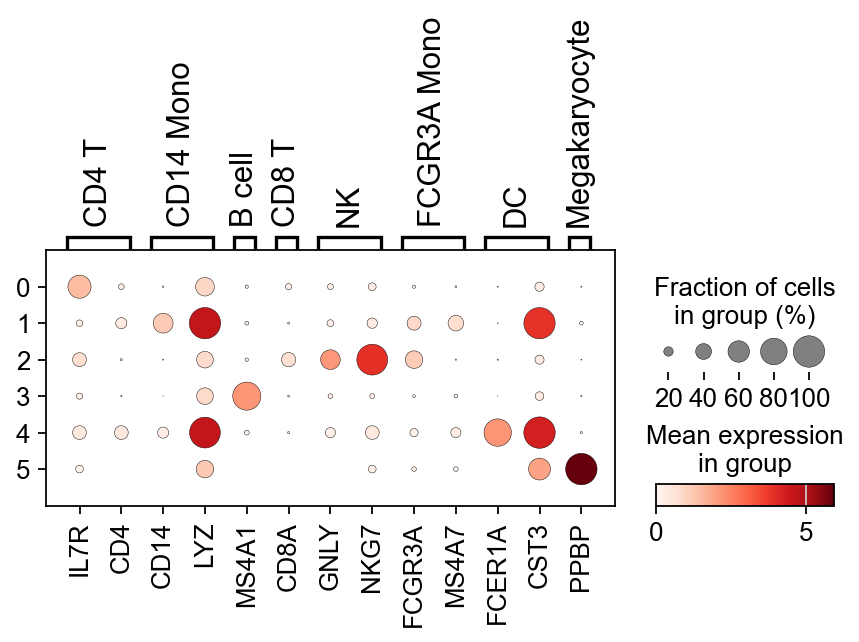

In [36]:
# Dotplot of known markers grouped by cluster
sc.pl.dotplot(
    adata,
    var_names=marker_genes_dict,
    groupby='leiden',
    save='_known_markers_dotplot.png'
)
plt.show()

### 7.1 Assign Cell Type Labels

Based on the marker gene expression patterns above, we assign cell type labels to clusters. (The exact mapping may vary slightly depending on resolution and random seed.)

In [37]:
# Map cluster numbers to cell types based on marker expression
# NOTE: Adjust this mapping after inspecting your marker plots!
cluster_to_celltype = {
    '0': 'CD4 T cells',
    '1': 'CD14 Monocytes',
    '2': 'B cells',
    '3': 'CD8 T cells',
    '4': 'NK cells',
    '5': 'FCGR3A Monocytes',
}

adata.obs['cell_type'] = adata.obs['leiden'].astype(str).map(cluster_to_celltype).fillna('Unknown')
print("Cell type counts:")
print(adata.obs['cell_type'].value_counts())

Cell type counts:
cell_type
CD4 T cells         1182
CD14 Monocytes       636
B cells              430
CD8 T cells          341
NK cells              36
FCGR3A Monocytes      13
Name: count, dtype: int64


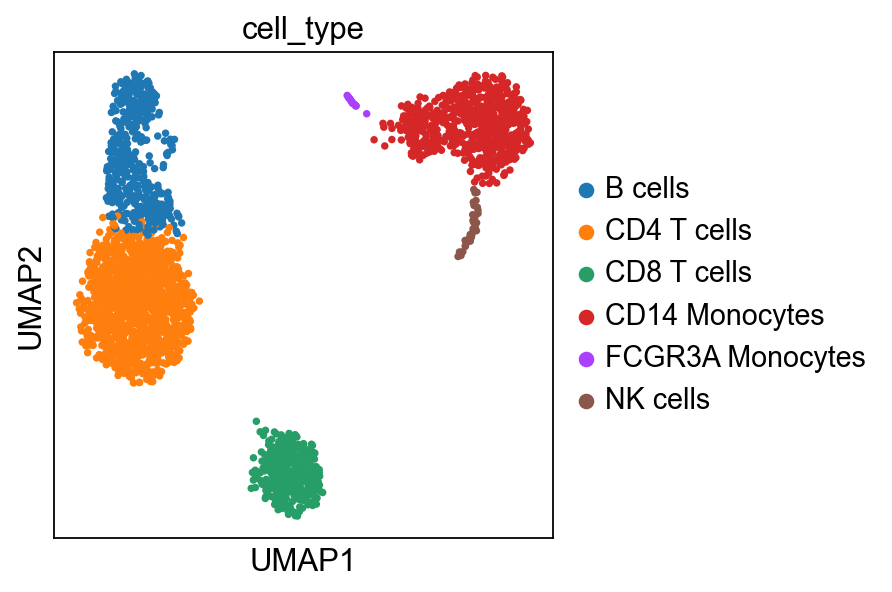

In [38]:
# Final UMAP with cell type labels
sc.pl.umap(adata, color='cell_type', save='_cell_types.png')
plt.show()

## 8. Save Clustered and Annotated Data

In [39]:
adata.write('output_data/clustered_adata.h5ad')
print(f"Saved: output_data/clustered_adata.h5ad")
print(f"\nFinal AnnData object:")
print(adata)

Saved: output_data/clustered_adata.h5ad

Final AnnData object:
AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'cell_type'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'rank_genes_groups', 'dendrogram_leiden', 'cell_type_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


---
## Summary

| Step | Function | Purpose |
|------|----------|---------|
| PCA | `sc.tl.pca()` | Reduce dimensionality, remove noise |
| Elbow plot | `sc.pl.pca_variance_ratio()` | Choose number of PCs to retain |
| Neighbors | `sc.pp.neighbors()` | Build k-NN graph in PCA space |
| UMAP | `sc.tl.umap()` | 2D embedding for visualization |
| Leiden | `sc.tl.leiden()` | Graph-based clustering |
| Marker genes | `sc.tl.rank_genes_groups()` | Differential expression per cluster |
| Dotplot/Heatmap | `sc.pl.dotplot()`, `sc.pl.rank_genes_groups_heatmap()` | Visualize marker expression |
| Annotation | manual mapping | Assign cell type identity |